# 最强总结！十大最优化算法！！

https://mp.weixin.qq.com/s/ywqSa8iEnQ8znOYn7n1cwQ

## 一阶优化算法

### 梯度下降法（Gradient Descent）
梯度下降法是一种常用的优化算法，用于求解函数的最小值或最大值。它通过迭代地更新参数的方式来逐步接近最优解。

假设我们要最小化一个可微函数 `f(x)` ，其中 `x` 是参数向量。梯度下降法的目标是找到使得 `f(x)` 达到最小值的 `x`。这个过程可以通过以下公式进行描述：

$x_{n+1} = x_n - \alpha \cdot \nabla f(x_n)$

其中，$x_n$ 表示第n次迭代的参数值，$\nabla f(x_n)$ 表示函数f在$x_n$处的梯度（即导数），$\alpha$ 称为学习率或步长，用于控制每次迭代的步幅。

具体而言，梯度下降法从任意初始点开始，根据当前位置的梯度方向（即函数下降最快的方向）以及学习率确定下一个位置，并不断迭代直到满足停止条件。当函数存在多个局部最小值时，梯度下降法可能会收敛到其中一个局部最优解。


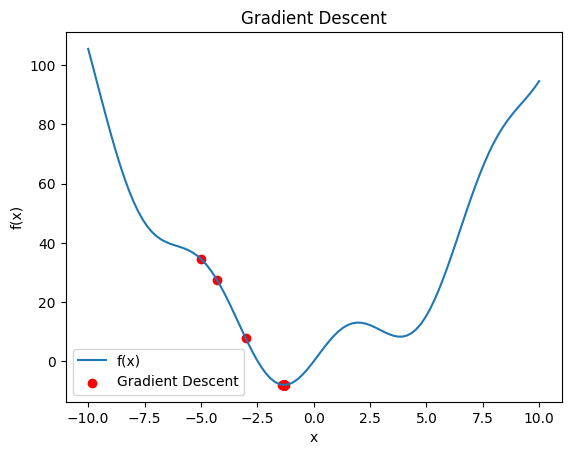

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(f, df, x0, learning_rate, num_iterations):
    x = x0
    x_history = [x]
    
    for _ in range(num_iterations):
        gradient = df(x)
        x -= learning_rate * gradient
        x_history.append(x)
    
    return np.array(x_history)

# 定义函数f(x)
def f(x):
    return x**2 + 10*np.sin(x)

# 定义函数f(x)的导数df(x)
def df(x):
    return 2*x + 10*np.cos(x)

# 设置初始参数值和学习率
x0 = -5
learning_rate = 0.1
num_iterations = 100

# 运行梯度下降算法
x_history = gradient_descent(f, df, x0, learning_rate, num_iterations)

# 绘制函数曲线和梯度下降路径
x_range = np.linspace(-10, 10, 100)
plt.plot(x_range, f(x_range), label='f(x)')
plt.scatter(x_history, f(np.array(x_history)), c='red', label='Gradient Descent')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient Descent')
plt.show()

这段代码会绘制函数f(x)的曲线以及梯度下降过程中的路径，以直观地展示梯度下降算法的工作原理。


### 随机梯度下降法（Stochastic Gradient Descent，SGD）
随机梯度下降法常用于训练机器学习模型。它的主要思想是通过迭代更新模型参数来最小化损失函数。

相比于传统的梯度下降法，SGD在每一次迭代中仅使用一个样本数据进行参数更新，因此计算速度更快。

SGD的公式如下：

$\theta = \theta - \eta \cdot \nabla J(\theta; x^{(i)}, y^{(i)})$

其中，$\theta$ 表示模型参数，$\eta$ 表示学习率，$J(\theta; x^{(i)}, y^{(i)})$ 表示损失函数关于参数$\theta$的梯度，$(x^{(i)}, y^{(i)})$ 表示第i个训练样本。

SGD的工作过程如下：
1. 初始化模型参数$\theta$；
2. 随机选择一个样本$(x^{(i)}, y^{(i)})$；
3. 计算损失函数关于参数$\theta$的梯度：$\nabla J(\theta; x^{(i)}, y^{(i)})$；
4. 更新参数$\theta$：$\theta = \theta - \eta \cdot \nabla J(\theta; x^{(i)}, y^{(i)})$；
5. 重复步骤2-4，直到达到停止条件（例如达到指定的迭代次数或损失函数下降到一定程度）。


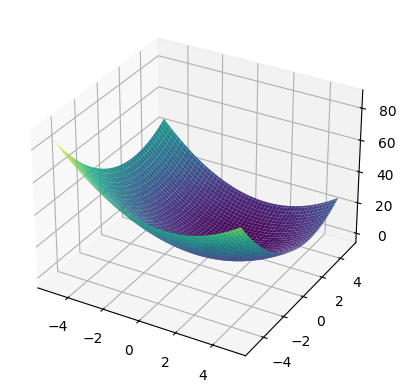

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 定义损失函数
def loss_function(x, y):
    return (x - 1) ** 2 + (y - 2) ** 2

# 定义梯度函数
def gradient(x, y):
    return np.array([2 * (x - 1), 2 * (y - 2)])

# 生成数据
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = loss_function(X, Y)

# 绘制3D图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

# SGD迭代更新参数
eta = 0.1
theta = np.array([0, 0])
num_iterations = 100
for i in range(num_iterations):
    gradient_value = gradient(theta[0], theta[1])
    theta = theta - eta * gradient_value
    ax.scatter(theta[0], theta[1], loss_function(theta[0], theta[1]), color='red')

plt.show()


### 小批量梯度下降法（Mini-batch Gradient Descent）
小批量梯度下降法是介于随机梯度下降法（SGD）和批量梯度下降法（BGD）之间的一种折中方法。

它将训练样本划分为多个批次（mini-batches），每个批次包含若干个样本。与SGD每次只使用一个样本进行参数更新相比，MBGD每次使用一个批次的样本进行参数更新。

MBGD的主要区别和优势如下：
- **计算效率**：与BGD相比，MBGD采用小批量样本进行参数更新，可以减少计算时间。尤其在大规模数据集上，MBGD通常比BGD更快。而与SGD相比，MBGD每次更新的样本数量更多，可以充分利用矩阵运算的并行性，加速参数更新过程。
- **稳定性**：MBGD相对于SGD具有更好的稳定性。由于MBGD每次使用多个样本进行参数更新，因此其参数更新方向相对于单个样本更加准确，避免了SGD中参数更新的高度不稳定问题。这使得MBGD在训练过程中更容易收敛到更好的局部最优解。
- **鲁棒性**：MBGD相对于SGD对噪声数据具有更好的鲁棒性。由于MBGD每次使用多个样本进行参数更新，它对于单个样本中的噪声信息会有所平均化，从而减少了单个样本对模型的影响。
- **泛化能力**：MBGD相对于SGD和BGD在一定程度上具有更好的泛化能力。与SGD相比，MBGD使用了更多的样本进行参数更新，可以更充分地表征数据集的特征；与BGD相比，MBGD采用了部分样本进行参数更新，避免了过度拟合的问题。

需要注意的是，MBGD的选择要根据具体问题的需求来确定。较小的批次大小可能会导致更快的收敛速度，但也可能陷入局部最优解。较大的批次大小可能导致计算变慢，但可能会获得更稳定的解。

因此，在实践中，我们通常需要根据数据集的规模、模型的复杂度和计算资源的限制等因素来选择适当的批次大小。

综上所述，MBGD是在SGD和BGD之间取得折中的一种优化算法，它在计算效率、稳定性、鲁棒性和泛化能力等方面都具有一定的优势。

## 二阶优化算法

### 牛顿法（Newton's Method）
牛顿法用于求解无约束优化问题。它通过利用二阶导数信息来近似地更新参数，从而更快地收敛到最优解。

牛顿法的公式如下：

$\theta = \theta - H^{-1}\cdot \nabla J(\theta)$

其中，$\theta$ 表示待优化的参数，$J(\theta)$ 表示目标函数，$\nabla J(\theta)$ 表示目标函数关于参数$\theta$的梯度，$H$ 表示目标函数关于参数$\theta_n$的黑塞矩阵。

牛顿法的工作过程如下：
1. 初始化参数$\theta$；
2. 计算目标函数关于参数$\theta$的梯度：$\nabla J(\theta)$；
3. 计算目标函数关于参数$\theta_n$的黑塞矩阵：$H$；
4. 更新参数$\theta$：$\theta = \theta - H^{-1}\cdot \nabla J(\theta)$；
5. 重复步骤2-4，直到达到停止条件（例如达到指定的迭代次数或梯度下降到一定程度）。

需要注意的是，牛顿法的收敛性和稳定性较好，但在某些情况下可能会受到黑塞矩阵的奇异性和计算复杂度的限制。因此，在实践中可能会使用牛顿法的一些改进版本，例如拟牛顿法（Quasi-Newton Methods），来克服这些问题。


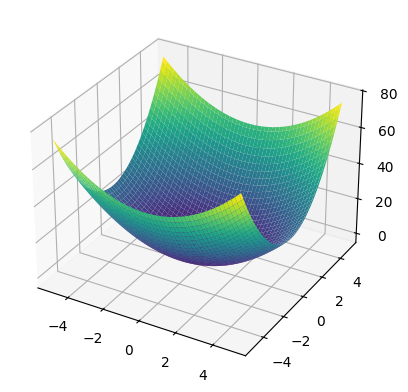

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 定义目标函数
def objective_function(x, y):
    return x**2 + 2*y**2

# 定义梯度函数
def gradient(x, y):
    return np.array([2*x, 4*y])

# 定义黑塞矩阵
def hessian_matrix():
    return np.array([[2, 0], [0, 4]])

# 生成数据
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# 绘制3D图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

# 牛顿法迭代更新参数
theta = np.array([0, 0])
num_iterations = 10
for i in range(num_iterations):
    gradient_value = gradient(theta[0], theta[1])
    hessian_inverse = np.linalg.inv(hessian_matrix())
    theta = theta - np.dot(hessian_inverse, gradient_value)
    ax.scatter(theta[0], theta[1], objective_function(theta[0], theta[1]), color='red')

plt.show()

在上述示例中，我们定义了一个简单的二维目标函数以及对应的梯度函数和黑塞矩阵。

然后，我们使用matplotlib库绘制了该函数的三维图形。

接着，我们使用牛顿法迭代更新参数，并在图中标示出每次迭代后的参数值。通过观察这些点的变化，可以更直观地理解牛顿法在参数空间中的搜索过程。

需要注意的是，牛顿法的收敛性和稳定性较好，但在某些情况下可能会受到黑塞矩阵的奇异性和计算复杂度的限制。因此，在实践中可能会使用牛顿法的一些改进版本，例如拟牛顿法（Quasi-Newton Methods），来克服这些问题。


### 拟牛顿法（Quasi-Newton Methods），如BFGS、L-BFGS
拟牛顿法用于求解无约束非线性优化问题。它通过逐步近似目标函数的二阶导数信息来更新搜索方向和步长，从而实现快速收敛。

拟牛顿法的核心思想是使用一个正定矩阵来近似目标函数的Hessian矩阵（二阶导数矩阵），从而避免了直接计算Hessian矩阵的复杂性。

其中最经典的拟牛顿法包括DFP（Davidon-Fletcher-Powell）和BFGS（Broyden-Fletcher-Goldfarb-Shanno）。

#### DFP算法
DFP算法的思想是通过迭代更新一个正定矩阵来近似Hessian矩阵。其迭代公式如下：

$H_{k+1} = H_k + \frac{\Delta x_k \Delta x_k^T}{\Delta x_k^T \Delta g_k} - \frac{H_k \Delta g_k \Delta g_k^T H_k}{\Delta g_k^T H_k \Delta g_k}$  
$\Delta x_k = x_{k+1} - x_k$  

其中，$x_k$ 表示第k次迭代的自变量，$g_k$ 表示第k次迭代的梯度，$H_k$ 表示第k次迭代的近似Hessian矩阵。

#### BFGS算法
BFGS算法同样是通过迭代更新一个正定矩阵来近似Hessian矩阵。其迭代公式如下：


$H_{k + 1} = (I - \rho_k s_k y_k^T)H_k(I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T$  
$s_k=x_{k+1}-x_k$  
$y_k=g_{k+1}-g_k$  
$p_k=\frac1{y_k^T s_k}$


其中，$x_k$ 表示第k次迭代的自变量，$g_k$ 表示第k次迭代的梯度，$H_k$ 表示第k次迭代的近似Hessian矩阵。

以下是一个简单的示例代码，在二维平面上绘制目标函数的等高线和拟牛顿法的迭代路径：

In [1]:
import numpy as np
import plotly.graph_objects as go

# 定义目标函数
def f(x, y):
    return x**2 + y**2

# 定义梯度函数
def gradient(x, y):
    return np.array([2*x, 2*y])

# 拟牛顿法迭代更新参数
def update_parameter(parameter, approx_hessian, gradient_value):
    parameter_delta = -np.dot(approx_hessian, gradient_value)
    new_parameter = parameter + parameter_delta
    gradient_delta = gradient(new_parameter[0], new_parameter[1]) - gradient_value
    rho = 1 / np.dot(gradient_delta, parameter_delta)
    outer_product = np.outer(parameter_delta, parameter_delta)
    approx_hessian += (rho * outer_product - np.dot(approx_hessian, outer_product) - np.dot(outer_product, approx_hessian)) / rho**2
    return new_parameter

# 初始化参数和近似黑塞矩阵
parameter = np.array([8, 8])
approx_hessian = np.eye(2)

# 进行拟牛顿法迭代
num_iterations = 20
path = [parameter]
for i in range(num_iterations):
    gradient_value = gradient(parameter[0], parameter[1])
    parameter = update_parameter(parameter, approx_hessian, gradient_value)
    path.append(parameter)

# 生成等高线数据
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# 绘制等高线和迭代路径
fig = go.Figure(data=[
    go.Contour(x=x, y=y, z=Z, contours=dict(coloring='lines')),
    go.Scatter3d(x=[p[0] for p in path], y=[p[1] for p in path], z=[f(p[0], p[1]) for p in path], mode='markers', marker=dict(size=5))
])

fig.show()

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_5772\2618665190.py:19: RuntimeWarning: divide by zero encountered in divide
  approx_hessian += (rho * outer_product - np.dot(approx_hessian, outer_product) - np.dot(outer_product, approx_hessian)) / rho**2
C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_5772\2618665190.py:19: RuntimeWarning: invalid value encountered in multiply
  approx_hessian += (rho * outer_product - np.dot(approx_hessian, outer_product) - np.dot(outer_product, approx_hessian)) / rho**2



### 共轭梯度法（Conjugate Gradient）
共轭梯度法是一种常用的无约束优化算法，特别适用于解决大规模线性方程组的求解问题。它利用梯度和残差的共轭性质，通过迭代寻找最优解。

共轭梯度法的基本思想是在每次迭代中选择一个共轭方向进行搜索，并通过最小化目标函数沿该方向的步长来更新参数。具体而言，假设我们要求解一个二次型目标函数：

$f(x) = \frac{1}{2}x^T Ax + b^T x$

其中，$x$ 表示自变量，$A$ 表示对称正定矩阵，$b$ 表示常数向量。

共轭梯度法的迭代公式如下：

$x_{k+1} = x_k + \alpha_k d_k$

$d_{k+1} = -r_{k+1} + \beta_k d_k$

其中，$x_k$ 表示第k次迭代的自变量，$d_k$ 表示第k次迭代的共轭方向，$\alpha_k$ 表示第k次迭代的步长，$r_k$ 表示第k次迭代的残差，$\beta_k$ 为系数。

共轭梯度法的步骤：
1. 初始化自变量$x_0$、共轭方向$d_0$和残差$r_0$。
2. 进行迭代，直到满足停止条件：
    - 计算步长$\alpha_k$:$\alpha_k = \frac{r_k^T r_k}{d_k^T A d_k}$：
    - 更新参数：$x_{k+1} = x_k + \alpha_k d_k$
    - 计算残差：$r_{k+1} = r_k - \alpha_k A d_k$
    - 计算系数$\beta_k$：$\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k}$（FR公式：调整搜索方向的权重）
    - 更新共轭方向：$d_{k+1} = -r_{k+1} + \beta_k d_k$

## 自适应学习率优化算法

### ADAM（Adaptive Moment Estimation）
ADAM 是一种自适应学习率优化算法，结合了RMSprop和Momentum的优点。

在深度学习中广泛应用，能够有效地调整学习率，加速模型收敛，并且具有较好的泛化性能。

ADAM算法的核心思想是根据梯度的一阶矩估计和二阶矩估计自适应地调整每个参数的学习率。下面是ADAM算法的公式：

初始化变量：$m_0 = 0$，$v_0 = 0$

在第t次迭代中，对于参数$\theta_t$计算梯度$g_t$

更新一阶矩估计：$m_t = \beta_1 * m_{t-1} + (1 - \beta_1) * g_t$

更新二阶矩估计：$v_t = \beta_2 * v_{t-1} + (1 - \beta_2) * g_t^2$

对偏差进行修正：$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$，$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$

更新参数：$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} *\hat{m}_t$

其中，$m_t$ 和$v_t$ 分别表示第t次迭代的一阶矩估计和二阶矩估计。$\beta_1$和$\beta_2$ 是用于控制历史梯度对估计的影响程度的超参数。$\eta$ 是学习率，$\epsilon$ 是一个很小的常数，用于保证分母不为零。

使用Python可以利用plotly库进行三维绘图，可以展示优化过程中损失函数在参数空间上的变化情况，以便更直观地理解ADAM算法的工作原理。

举一个例子：

这段代码可以绘制出一个损失函数在参数空间中的曲面图，从而可视化ADAM算法优化过程中参数收敛的情况。

In [2]:
import plotly.graph_objects as go

# 定义损失函数
def loss_function(x, y):
    return x**2 + y**2

# 设置参数空间
theta_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(theta_range, theta_range)
Z = loss_function(X, Y)

# 绘制三维图像
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y)])
fig.update_layout(title='Loss Function',
                  scene=dict(
                      xaxis_title='Theta1',
                      yaxis_title='Theta2',
                      zaxis_title='Loss'))
fig.show()


### RMSProp（Root Mean Square Propagation）
RMSProp 是一种自适应学习率优化算法，用于调整神经网络中每个参数的学习率。

它通过计算梯度历史信息的均方根来自适应地调整学习率大小，从而加快模型收敛速度。

RMSProp算法的公式如下：

初始化变量：$v_0 = 0$

在第t次迭代中，对于参数$\theta_t$计算梯度$g_t$

更新二阶矩估计：$v_t = \beta*v_{t-1} + (1 - \beta)* g_t^2$

更新参数：$\theta_{t+1} = \theta_{t} - \frac{\eta}{\sqrt{v_t} + \epsilon}*g_t$

其中，$v_t$ 表示第t次迭代的二阶矩估计，$\beta$ 是一个用于控制历史梯度对估计影响程度的超参数。$\eta$ 是学习率，$\epsilon$ 是一个很小的常数，用于保证分母不为零。

### AdaGrad
AdaGrad 是一种自适应学习率优化算法，用于调整神经网络中每个参数的学习率。

它根据梯度的历史信息来自适应地调整学习率的大小，使得对于经常出现的稀疏特征，其学习率较小，而对于不经常出现的特征，其学习率较大。

AdaGrad算法的公式如下：

初始化变量：$G_0 = 0$

在第t次迭代中，对于参数$\theta_t$计算梯度$g_t$

更新历史梯度累积：$G_t = G_{t-1} + g_t^2$

更新参数：$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon}*g_t$

其中，$G_t$ 表示第t次迭代的历史梯度累积。$\eta$是学习率，$\epsilon$ 是一个很小的常数，用于保证分母不为零。

## 基于线性规划的优化算法

### 线性规划（Linear Programming）
线性规划旨在找到一个线性目标函数的最小值或最大值，并满足一组线性等式和不等式约束条件。

线性规划的一般形式可以表示为：

最小化（或最大化）$C^T*X$

约束条件：  
$A*X < B$  
$A_{eq}*X = B_{eq}$  

其中，$X$ 是待求解的决策变量向量，$C$ 是目标函数的系数向量，$A$和$B$ 是不等式约束条件的系数矩阵和向量，$A_{eq}$和$b_{eq}$ 是等式约束条件的系数矩阵和向量。

通过Python和plotly库，我们可以绘制线性规划问题的可行域（feasible region）和目标函数在可行域上的等高线图，从而直观地理解线性规划的工作原理。

以下是一个示例代码，假设我们要最小化目标函数$z=3x+4y$，并且满足以下约束条件：  
$x \geq 0$  
$y \geq 0$  
$x+y \leq 6$  
$2x+y \leq 8$

In [3]:
import numpy as np
import plotly.graph_objects as go

# 定义目标函数和约束条件
def objective_function(x, y):
    return 3 * x + 4 * y

def constraint1(x, y):
    return x + y - 6

def constraint2(x, y):
    return 2 * x + y - 8

# 设置参数空间
x_range = np.linspace(0, 10, 100)
y_range = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = objective_function(X, Y)

# 绘制等高线图
fig = go.Figure(data=[go.Contour(z=Z, x=X, y=Y)])
fig.update_layout(title='Objective Function',
                  xaxis_title='x',
                  yaxis_title='y')
fig.show()


### 整数规划（Integer Programming）
整数规划是线性规划的一种扩展形式，在整数规划中，决策变量被限制为整数值。与线性规划相比，整数规划更加复杂且计算上更具挑战性。

整数规划的一般形式可以表示为：

最小化（或最大化）：$C^T * X$

约束条件：  
$A*X \leq B$  
$A_{eq}*X = B_{eq}$  
$X$的元素为整数

其中，$X$ 是待求解的决策变量向量，$C$ 是目标函数的系数向量，$A$和$B$ 是不等式约束条件的系数矩阵和向量，$A_{eq}$和$B_{eq}$ 是等式约束条件的系数矩阵和向量。

整数规划问题通常比线性规划问题更难求解，因为整数变量的离散性质使得问题空间更大。求解整数规划问题的方法包括分支定界法（branch and bound）、割平面法（cutting plane method）、混合整数线性规划（mixed integer linear programming, MILP）等。

## 具有约束条件的优化算法

### 条件梯度法（Conditional Gradient Method），也称为Frank-Wolfe算法
条件梯度法（Method of Constrained Gradients）是一种用于求解具有约束条件的优化问题的数值方法。它结合了梯度下降法和拉格朗日乘子法，通过在梯度方向上进行搜索来找到满足约束条件的最优解。

考虑一个带有等式约束条件的优化问题：

最小化（或最大化）目标函数：$f(x1,x2,....,xn)$

约束条件：$g_i(x1,x2,....,xn)) = 0$，其中$i = 1,2,...,m$

条件梯度法的基本思想是在每个迭代步骤中，使用拉格朗日乘子法构造一个逼近的目标函数，并沿着该目标函数的负梯度方向更新变量。这样可以逐步接近原始问题的最优解，并同时满足约束条件。

条件梯度法的迭代步骤如下：
1. 初始化决策变量$x$和拉格朗日乘子$\lambda$的初始值。
2. 计算目标函数$f$和约束函数$g$的梯度向量$\nabla f$和$\nabla g$。
3. 更新决策变量的值：$x^{(k+1)} = x^{(k)} - \alpha \nabla f$，其中$\alpha$是步长。
4. 使用拉格朗日乘子法更新拉格朗日乘子：$\lambda^{(k+1)} = \lambda^{(k)} + \beta_g$，其中$\beta$是步长。
5. 如果满足终止条件（例如达到最大迭代次数或目标函数的收敛性），则停止迭代；否则返回第2步。

通过Python和plotly库，我们可以绘制优化问题的目标函数在参数空间中的等高线图，并可视化约束条件。


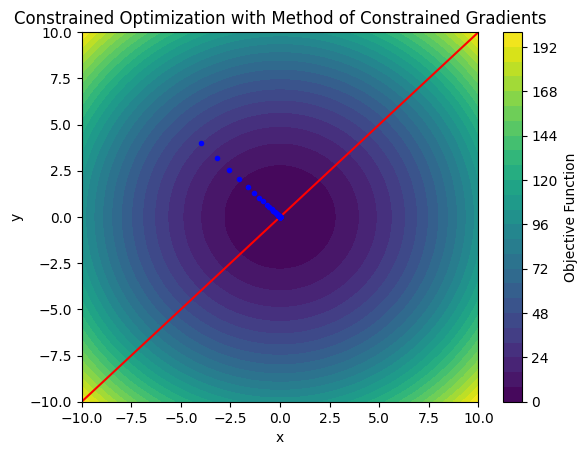

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# 定义目标函数和约束条件
def objective_function(x, y):
    return x**2 + y**2

def constraint(x, y):
    return x - y

# 设置参数空间
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# 绘制等高线图
plt.contourf(X, Y, Z, levels=30, cmap='viridis')
plt.colorbar(label='Objective Function')

# 绘制约束条件
plt.contour(X, Y, constraint(X, Y), levels=[0], colors='r')

# 执行条件梯度法迭代过程
x_init = -5.0
y_init = 5.0
alpha = 0.1  # 步长

for _ in range(100):
    x_grad = 2 * x_init
    y_grad = 2 * y_init
    
    x_init -= alpha * x_grad
    y_init -= alpha * y_grad
    
    plt.plot(x_init, y_init, 'bo', markersize=3)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Constrained Optimization with Method of Constrained Gradients')

plt.show()

这段代码使用numpy库定义目标函数和约束条件，并使用matplotlib库绘制出目标函数的等高线图。通过执行条件梯度法的迭代过程，我们可以在参数空间中看到优化过程的轨迹。

### 基于投影的优化算法，如投影梯度下降法（Projected Gradient Descent）
基于投影的优化算法（Projected Gradient Algorithm）是一种用于求解具有约束条件的优化问题的方法。

它通过在每个迭代步骤中将更新后的变量投影到可行域内来满足约束条件。

考虑一个带有等式和不等式约束条件的优化问题：

最小化（或最大化）目标函数：$f(x_1,x_2,...，x_n)$

约束条件：  
$g_i(x_1,x_2,...，x_n) = 0$，其中$i = 1,2,...,m$  
$h_j(x_1,x_2,...，x_n) \leq 0$，其中$j = 1,2,...,p$  

基于投影的优化算法的基本思想是在每个迭代步骤中，计算目标函数的梯度，并根据梯度方向更新变量。然后将更新后的变量投影到可行域内，以满足约束条件。这样可以逐步接近原始问题的最优解，并同时满足约束条件。

基于投影的优化算法的迭代步骤如下：
1. 初始化决策变量$x$的初始值。
2. 计算目标函数$f$的梯度向量$\nabla f$。
3. 更新决策变量的值：$x^{(k+1)} = x^{(k)} - \alpha \nabla f$，其中$\alpha$是步长。
4. 对更新后的变量进行投影操作以满足约束条件：$x^{(k+1)} = P(x^{(k+1)})$，其中$P(\cdot)$表示投影操作。
5. 如果满足终止条件（例如达到最大迭代次数或目标函数的收敛性），则停止迭代；否则返回第2步。

## 具有全局收敛性的优化算法

### 全局优化算法，如随机搜索、模拟退火、遗传算法等
具有全局收敛性的优化算法是用于求解全局最优解的优化算法。

咱们这里用随机搜索来举例，是其中一种简单但非常直观的全局优化算法，它通过在搜索空间中随机采样候选解来寻找最优解。随机搜索是一种简单而直接的全局优化算法，它不依赖于梯度信息，而是通过在搜索空间中随机采样来探索可能的解。其基本流程如下：

1. 在给定的搜索空间中随机采样一个候选解
2. 计算该候选解对应的目标函数值
3. 如果目标函数值更优，则更新最优解
4. 重复上述步骤直至满足终止条件（例如达到最大迭代次数）

随机搜索的公式详解可以表示为：


解采样：$x\sim U(a, b)$  
目标函数值计算：$f(x)$  
最优解更新：$x_{best} = \arg\min f(x)$

随机搜索算法的优点是易于实现和理解，适用于没有显式表达式或梯度信息的目标函数。

然而，由于其随机性，它可能需要更多的采样次数才能达到较好的结果。

**举个例子，下列代码中：**

首先定义了目标函数，然后生成网格点用于绘制曲面图。

在随机搜索中，通过随机采样候选解，并计算其对应的目标函数值。

然后，更新最优解，如果发现更好的解。最后，将最优解以红色点的形式添加到三维图中。

In [2]:
import numpy as np
import plotly.graph_objects as go

# 定义目标函数
def objective_function(x, y):
    return np.sin(x) + np.cos(y)

# 生成网格点
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# 随机搜索
num_iterations = 100
best_solution = None
best_fitness = float('inf')

for _ in range(num_iterations):
    # 随机采样候选解
    candidate_solution = [np.random.uniform(-5, 5), np.random.uniform(-5, 5)]
    
    # 计算目标函数值
    fitness = objective_function(candidate_solution[0], candidate_solution[1])
    
    # 更新最优解
    if fitness < best_fitness:
        best_solution = candidate_solution
        best_fitness = fitness

# 绘制三维图像
fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z)])
fig.add_trace(go.Scatter3d(x=[best_solution[0]], y=[best_solution[1]], z=[best_fitness],
                           mode='markers', marker=dict(size=5, color='red')))
fig.update_layout(title='Objective Function with Best Solution from Random Search', autosize=False,
                  width=700, height=500, scene=dict(
                      xaxis_title='X',
                      yaxis_title='Y',
                      zaxis_title='Z'
                  ))
fig.show()

## **~结束~**
### 下列是大预言模型生成的公式Markdown 公式存在变体


## 一阶优化算法

### 梯度下降法（Gradient Descent）
梯度下降法是一种常用的优化算法，用于求解函数的最小值或最大值。它通过迭代地更新参数的方式来逐步接近最优解。

假设我们要最小化一个可微函数 `f(x)` ，其中 `x` 是参数向量。梯度下降法的目标是找到使得 `f(x)` 达到最小值的 `x`。这个过程可以通过以下公式进行描述：

$x_{n+1} = x_n - \alpha \nabla f(x_n)$

其中，$x_n$ 表示第n次迭代的参数值，$\nabla f(x_n)$ 表示函数f在$x_n$处的梯度（即导数），$\alpha$ 称为学习率或步长，用于控制每次迭代的步幅。

具体而言，梯度下降法从任意初始点开始，根据当前位置的梯度方向（即函数下降最快的方向）以及学习率确定下一个位置，并不断迭代直到满足停止条件。当函数存在多个局部最小值时，梯度下降法可能会收敛到其中一个局部最优解。

### 随机梯度下降法（Stochastic Gradient Descent，SGD）
随机梯度下降法常用于训练机器学习模型。它的主要思想是通过迭代更新模型参数来最小化损失函数。

相比于传统的梯度下降法，SGD在每一次迭代中仅使用一个样本数据进行参数更新，因此计算速度更快。

SGD的公式如下：

$\theta = \theta - \alpha \nabla L(\theta; x_i, y_i)$

其中，$\theta$ 表示模型参数，$\alpha$ 表示学习率，$\nabla L(\theta; x_i, y_i)$ 表示损失函数关于参数$\theta$的梯度，$(x_i, y_i)$ 表示第i个训练样本。

SGD的工作过程如下：
1. 初始化模型参数$\theta$；
2. 随机选择一个样本$(x_i, y_i)$；
3. 计算损失函数关于参数$\theta$的梯度：$\nabla L(\theta; x_i, y_i)$；
4. 更新参数$\theta$：$\theta = \theta - \alpha \nabla L(\theta; x_i, y_i)$；
5. 重复步骤2-4，直到达到停止条件（例如达到指定的迭代次数或损失函数下降到一定程度）。

### 小批量梯度下降法（Mini-batch Gradient Descent）
小批量梯度下降法是介于随机梯度下降法（SGD）和批量梯度下降法（BGD）之间的一种折中方法。

它将训练样本划分为多个批次（mini-batches），每个批次包含若干个样本。与SGD每次只使用一个样本进行参数更新相比，MBGD每次使用一个批次的样本进行参数更新。

MBGD的主要区别和优势如下：
- 计算效率：与BGD相比，MBGD采用小批量样本进行参数更新，可以减少计算时间。尤其在大规模数据集上，MBGD通常比BGD更快。而与SGD相比，MBGD每次更新的样本数量更多，可以充分利用矩阵运算的并行性，加速参数更新过程。
- 稳定性：MBGD相对于SGD具有更好的稳定性。由于MBGD每次使用多个样本进行参数更新，因此其参数更新方向相对于单个样本更加准确，避免了SGD中参数更新的高度不稳定问题。这使得MBGD在训练过程中更容易收敛到更好的局部最优解。
- 鲁棒性：MBGD相对于SGD对噪声数据具有更好的鲁棒性。由于MBGD每次使用多个样本进行参数更新，它对于单个样本中的噪声信息会有所平均化，从而减少了单个样本对模型的影响。
- 泛化能力：MBGD相对于SGD和BGD在一定程度上具有更好的泛化能力。与SGD相比，MBGD使用了更多的样本进行参数更新，可以更充分地表征数据集的特征；与BGD相比，MBGD采用了部分样本进行参数更新，避免了过度拟合的问题。

需要注意的是，MBGD的选择要根据具体问题的需求来确定。较小的批次大小可能会导致更快的收敛速度，但也可能陷入局部最优解。较大的批次大小可能导致计算变慢，但可能会获得更稳定的解。

因此，在实践中，我们通常需要根据数据集的规模、模型的复杂度和计算资源的限制等因素来选择适当的批次大小。

综上所述，MBGD是在SGD和BGD之间取得折中的一种优化算法，它在计算效率、稳定性、鲁棒性和泛化能力等方面都具有一定的优势。

## 二阶优化算法

### 牛顿法（Newton's Method）
牛顿法用于求解无约束优化问题。它通过利用二阶导数信息来近似地更新参数，从而更快地收敛到最优解。

牛顿法的公式如下：

$\theta_{n+1} = \theta_n - H^{-1}(\theta_n) \nabla f(\theta_n)$

其中，$\theta$ 表示待优化的参数，$f(\theta)$ 表示目标函数，$\nabla f(\theta_n)$ 表示目标函数关于参数$\theta_n$的梯度，$H(\theta_n)$ 表示目标函数关于参数$\theta_n$的黑塞矩阵。

牛顿法的工作过程如下：
1. 初始化参数$\theta_0$；
2. 计算目标函数关于参数$\theta_n$的梯度：$\nabla f(\theta_n)$；
3. 计算目标函数关于参数$\theta_n$的黑塞矩阵：$H(\theta_n)$；
4. 更新参数$\theta_{n+1}$：$\theta_{n+1} = \theta_n - H^{-1}(\theta_n) \nabla f(\theta_n)$；
5. 重复步骤2-4，直到达到停止条件（例如达到指定的迭代次数或梯度下降到一定程度）。

需要注意的是，牛顿法的收敛性和稳定性较好，但在某些情况下可能会受到黑塞矩阵的奇异性和计算复杂度的限制。因此，在实践中可能会使用牛顿法的一些改进版本，例如拟牛顿法（Quasi-Newton Methods），来克服这些问题。

### 拟牛顿法（Quasi-Newton Methods），如BFGS、L-BFGS
拟牛顿法用于求解无约束非线性优化问题。它通过逐步近似目标函数的二阶导数信息来更新搜索方向和步长，从而实现快速收敛。

拟牛顿法的核心思想是使用一个正定矩阵来近似目标函数的Hessian矩阵（二阶导数矩阵），从而避免了直接计算Hessian矩阵的复杂性。

其中最经典的拟牛顿法包括DFP（Davidon-Fletcher-Powell）和BFGS（Broyden-Fletcher-Goldfarb-Shanno）。

#### DFP算法
DFP算法的思想是通过迭代更新一个正定矩阵来近似Hessian矩阵。其迭代公式如下：

$H_{k+1} = H_k + \frac{\Delta x_k \Delta x_k^T}{\Delta x_k^T \Delta g_k} - \frac{H_k \Delta g_k \Delta g_k^T H_k}{\Delta g_k^T H_k \Delta g_k}$

其中，$x_k$ 表示第k次迭代的自变量，$g_k$ 表示第k次迭代的梯度，$H_k$ 表示第k次迭代的近似Hessian矩阵，$\Delta x_k = x_{k+1} - x_k$，$\Delta g_k = g_{k+1} - g_k$。

#### BFGS算法
BFGS算法同样是通过迭代更新一个正定矩阵来近似Hessian矩阵。其迭代公式如下：

$H_{k+1} = H_k + (1 + \frac{\Delta g_k^T H_k \Delta g_k}{\Delta x_k^T \Delta g_k}) \frac{\Delta x_k \Delta x_k^T}{\Delta x_k^T \Delta g_k} - \frac{\Delta x_k \Delta g_k^T H_k + H_k \Delta g_k \Delta x_k^T}{\Delta x_k^T \Delta g_k}$

其中，$x_k$ 表示第k次迭代的自变量，$g_k$ 表示第k次迭代的梯度，$H_k$ 表示第k次迭代的近似Hessian矩阵，$\Delta x_k = x_{k+1} - x_k$，$\Delta g_k = g_{k+1} - g_k$。

### 共轭梯度法（Conjugate Gradient）
共轭梯度法是一种常用的无约束优化算法，特别适用于解决大规模线性方程组的求解问题。它利用梯度和残差的共轭性质，通过迭代寻找最优解。

共轭梯度法的基本思想是在每次迭代中选择一个共轭方向进行搜索，并通过最小化目标函数沿该方向的步长来更新参数。具体而言，假设我们要求解一个二次型目标函数：

$f(x) = \frac{1}{2}x^T Ax + b^T x$

其中，$x$ 表示自变量，$A$ 表示对称正定矩阵，$b$ 表示常数向量。

共轭梯度法的迭代公式如下：

$x_{k+1} = x_k + \alpha_k d_k$

$r_{k+1} = r_k - \alpha_k A d_k$

$\beta_k = \frac{r_{k+1}^T A d_k}{d_k^T A d_k}$（或其他形式）

$d_{k+1} = -r_{k+1} + \beta_k d_k$

其中，$x_k$ 表示第k次迭代的自变量，$d_k$ 表示第k次迭代的共轭方向，$\alpha_k$ 表示第k次迭代的步长，$r_k$ 表示第k次迭代的残差，$\beta_k$ 为系数。

共轭梯度法的步骤：
1. 初始化自变量$x_0$、共轭方向$d_0 = -r_0$和残差$r_0 = Ax_0 + b$。
2. 进行迭代，直到满足停止条件：
    - 计算步长$\alpha_k = \frac{r_k^T r_k}{d_k^T A d_k}$：
    - 更新参数：$x_{k+1} = x_k + \alpha_k d_k$
    - 计算残差：$r_{k+1} = r_k - \alpha_k A d_k$
    - 计算系数$\beta_k$：$\beta_k = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k}$（FR公式）
    - 更新共轭方向：$d_{k+1} = -r_{k+1} + \beta_k d_k$

## 自适应学习率优化算法

### ADAM（Adaptive Moment Estimation）
ADAM 是一种自适应学习率优化算法，结合了RMSprop和Momentum的优点。

在深度学习中广泛应用，能够有效地调整学习率，加速模型收敛，并且具有较好的泛化性能。

ADAM算法的核心思想是根据梯度的一阶矩估计和二阶矩估计自适应地调整每个参数的学习率。下面是ADAM算法的公式：

初始化变量：$m_0 = 0$，$v_0 = 0$，$t = 0$

在第t次迭代中，对于参数$\theta$计算梯度$g_t = \nabla_\theta L(\theta)$

更新一阶矩估计：$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$

更新二阶矩估计：$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$

对偏差进行修正：$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$，$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$

更新参数：$\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

其中，$m_t$ 和$v_t$ 分别表示第t次迭代的一阶矩估计和二阶矩估计。$\beta_1$和$\beta_2$ 是用于控制历史梯度对估计的影响程度的超参数。$\alpha$ 是学习率，$\epsilon$ 是一个很小的常数，用于保证分母不为零。

### RMSProp（Root Mean Square Propagation）
RMSProp 是一种自适应学习率优化算法，用于调整神经网络中每个参数的学习率。

它通过计算梯度历史信息的均方根来自适应地调整学习率大小，从而加快模型收敛速度。

RMSProp算法的公式如下：

初始化变量：$E[g^2]_0 = 0$

在第t次迭代中，对于参数$\theta$计算梯度$g_t = \nabla_\theta L(\theta)$

更新二阶矩估计：$E[g^2]_t = \beta E[g^2]_{t-1} + (1 - \beta) g_t^2$

更新参数：$\theta_t = \theta_{t-1} - \alpha \frac{g_t}{\sqrt{E[g^2]_t} + \epsilon}$

其中，$E[g^2]_t$ 表示第t次迭代的二阶矩估计，$\beta$ 是一个用于控制历史梯度对估计影响程度的超参数。$\alpha$ 是学习率，$\epsilon$ 是一个很小的常数，用于保证分母不为零。

### AdaGrad
AdaGrad 是一种自适应学习率优化算法，用于调整神经网络中每个参数的学习率。

它根据梯度的历史信息来自适应地调整学习率的大小，使得对于经常出现的稀疏特征，其学习率较小，而对于不经常出现的特征，其学习率较大。

AdaGrad算法的公式如下：

初始化变量：$r_0 = 0$

在第t次迭代中，对于参数$\theta$计算梯度$g_t = \nabla_\theta L(\theta)$

更新历史梯度累积：$r_t = r_{t-1} + g_t^2$

更新参数：$\theta_t = \theta_{t-1} - \alpha \frac{g_t}{\sqrt{r_t} + \epsilon}$

其中，$r_t$ 表示第t次迭代的历史梯度累积。$\alpha$是学习率，$\epsilon$ 是一个很小的常数，用于保证分母不为零。

## 基于线性规划的优化算法

### 线性规划（Linear Programming）
线性规划旨在找到一个线性目标函数的最小值或最大值，并满足一组线性等式和不等式约束条件。

线性规划的一般形式可以表示为：

最小化（或最大化）$c^T x$

约束条件：
$Ax \leq b$
$A_{eq}x = b_{eq}$
$l \leq x \leq u$

其中，$x$ 是待求解的决策变量向量，$c$ 是目标函数的系数向量，$A$和$b$ 是不等式约束条件的系数矩阵和向量，$A_{eq}$和$b_{eq}$ 是等式约束条件的系数矩阵和向量，$l$和$u$是决策变量的下界和上界。

### 整数规划（Integer Programming）
整数规划是线性规划的一种扩展形式，在整数规划中，决策变量被限制为整数值。与线性规划相比，整数规划更加复杂且计算上更具挑战性。

整数规划的一般形式可以表示为：

最小化（或最大化）：$c^T x$

约束条件：
$Ax \leq b$
$A_{eq}x = b_{eq}$
$l \leq x \leq u$
$x$的元素为整数

其中，$x$ 是待求解的决策变量向量，$c$ 是目标函数的系数向量，$A$和$b$ 是不等式约束条件的系数矩阵和向量，$A_{eq}$和$b_{eq}$ 是等式约束条件的系数矩阵和向量，$l$和$u$是决策变量的下界和上界。

整数规划问题通常比线性规划问题更难求解，因为整数变量的离散性质使得问题空间更大。求解整数规划问题的方法包括分支定界法（branch and bound）、割平面法（cutting plane method）、混合整数线性规划（mixed integer linear programming, MILP）等。

## 具有约束条件的优化算法

### 条件梯度法（Conditional Gradient Method），也称为Frank-Wolfe算法
条件梯度法（Method of Constrained Gradients）是一种用于求解具有约束条件的优化问题的数值方法。它结合了梯度下降法和拉格朗日乘子法，通过在梯度方向上进行搜索来找到满足约束条件的最优解。

考虑一个带有等式约束条件的优化问题：

最小化（或最大化）目标函数：$f(x)$

约束条件：$h_i(x) = 0$，其中$i = 1,2,...,m$

条件梯度法的基本思想是在每个迭代步骤中，使用拉格朗日乘子法构造一个逼近的目标函数，并沿着该目标函数的负梯度方向更新变量。这样可以逐步接近原始问题的最优解，并同时满足约束条件。

条件梯度法的迭代步骤如下：
1. 初始化决策变量$x_0$和拉格朗日乘子$\lambda_0$的初始值。
2. 计算目标函数$f(x)$和约束函数$h_i(x)$的梯度向量$\nabla f(x_k)$和$\nabla h_i(x_k)$。
3. 更新决策变量的值：$x_{k+1} = x_k - \alpha_k (\nabla f(x_k) + \sum_{i=1}^m \lambda_i \nabla h_i(x_k))$，其中$\alpha_k$是步长。
4. 使用拉格朗日乘子法更新拉格朗日乘子：$\lambda_{k+1} = \lambda_k + \beta_k h_i(x_{k+1})$，其中$\beta_k$是步长。
5. 如果满足终止条件（例如达到最大迭代次数或目标函数的收敛性），则停止迭代；否则返回第2步。

### 基于投影的优化算法，如投影梯度下降法（Projected Gradient Descent）
基于投影的优化算法（Projected Gradient Algorithm）是一种用于求解具有约束条件的优化问题的方法。

它通过在每个迭代步骤中将更新后的变量投影到可行域内来满足约束条件。

考虑一个带有等式和不等式约束条件的优化问题：

最小化（或最大化）目标函数：$f(x)$

约束条件：
$h_i(x) = 0$，其中$i = 1,2,...,m$
$g_j(x) \leq 0$，其中$j = 1,2,...,p$

基于投影的优化算法的基本思想是在每个迭代步骤中，计算目标函数的梯度，并根据梯度方向更新变量。然后将更新后的变量投影到可行域内，以满足约束条件。这样可以逐步接近原始问题的最优解，并同时满足约束条件。

基于投影的优化算法的迭代步骤如下：
1. 初始化决策变量$x_0$的初始值。
2. 计算目标函数$f(x)$的梯度向量$\nabla f(x_k)$。
3. 更新决策变量的值：$x_{k+1}^{temp} = x_k - \alpha_k \nabla f(x_k)$，其中$\alpha_k$是步长。
4. 对更新后的变量进行投影操作以满足约束条件：$x_{k+1} = P(x_{k+1}^{temp})$，其中$P(\cdot)$表示投影操作。
5. 如果满足终止条件（例如达到最大迭代次数或目标函数的收敛性），则停止迭代；否则返回第2步。

## 具有全局收敛性的优化算法

### 全局优化算法，如随机搜索、模拟退火、遗传算法等
具有全局收敛性的优化算法是用于求解全局最优解的优化算法。

咱们这里用随机搜索来举例，是其中一种简单但非常直观的全局优化算法，它通过在搜索空间中随机采样候选解来寻找最优解。随机搜索是一种简单而直接的全局优化算法，它不依赖于梯度信息，而是通过在搜索空间中随机采样来探索可能的解。其基本流程如下：

1. 在给定的搜索空间中随机采样一个候选解$x_{candidate}$
2. 计算该候选解对应的目标函数值$f(x_{candidate})$
3. 如果目标函数值更优，则更新最优解$x_{best} = x_{candidate}$
4. 重复上述步骤直至满足终止条件（例如达到最大迭代次数）

随机搜索的公式详解可以表示为：

$x_{candidate} \sim U(a, b)$（其中$U(a, b)$表示在区间$[a, b]$上的均匀分布）

$x_{best} = \arg\min_{x \in \{x_{candidate}^1, x_{candidate}^2, ..., x_{candidate}^N\}} f(x)$

随机搜索算法的优点是易于实现和理解，适用于没有显式表达式或梯度信息的目标函数。

然而，由于其随机性，它可能需要更多的采样次数才能达到较好的结果。



## - 附录和笔记
### 大语言模型生成的关于部分数学符号及公式的解释


在数学和机器学习中，$\nabla$（nabla）符号是**梯度（Gradient）**的标志，它是多元函数微分学里的核心概念之一，专门用来处理“多变量函数的变化率”问题。结合你给出的梯度下降公式 $x_{n+1} = x_n - \alpha \cdot \nabla f(x_n)$ ，可以从这几个角度理解它：

### 1. 本质含义：“多变量的导数”
如果是单变量函数（比如 $f(x) = x^2$ ，只有一个变量 $x$ ），我们用普通导数 $f'(x)$ 表示函数的变化率；但如果是**多变量函数**（比如 $f(x,y) = x^2 + y^2$ ，有 $x$ 和 $y$ 两个变量 ），单个导数无法完整描述“函数在各个方向怎么变”，这时候就需要**梯度** $\nabla f$ ，它把函数对**每个变量的偏导数**打包成一个向量，完整刻画函数的变化趋势。  

对多变量函数 $f(x_1, x_2, \dots, x_d)$（比如机器学习里模型参数是 $d$ 维向量 ），梯度的定义是：  
$$
\nabla f = \left( \frac{\partial f}{\partial x_1},\ \frac{\partial f}{\partial x_2},\ \dots,\ \frac{\partial f}{\partial x_d} \right)
$$  
每一个分量 $\frac{\partial f}{\partial x_i}$ 就是函数 $f$ 对单个变量 $x_i$ 的“偏导数”（固定其他变量不变，只看 $x_i$ 变化时 $f$ 的变化率 ）。  


### 2. 在梯度下降里的作用：“指明函数下降最快的方向”
梯度下降的目标是找函数 $f(x)$ 的最小值，核心逻辑是**“往函数下降最快的方向走一小步”** ，而 $\nabla f(x_n)$ 恰好就是这个“下降最快方向的反方向”（严格说：梯度向量的方向是函数**上升最快**的方向，所以减梯度就是“下降最快”方向 ）。  

- 比如你想找山谷（函数最小值），每一步站在位置 $x_n$ ，计算当前点的梯度 $\nabla f(x_n)$ ，它会告诉你“往哪个方向走，函数值会快速变大”；那反过来，你**减去**这个梯度方向（乘以学习率 $\alpha$ 控制步长 ），就能往“函数值快速变小”的方向迈一步，逐步逼近最小值。  


### 3. 直观类比：单变量导数的“高维扩展”
- 单变量函数（比如 $f(x) = x^2$ ），导数 $f'(x) = 2x$ ，它决定了你“在 $x$ 点往哪个方向走，函数值会上升/下降”（导数正，往右走上升；导数负，往左走上升 ）。  
- 多变量函数（比如 $f(x,y) = x^2 + y^2$ ），梯度 $\nabla f = (2x,\ 2y)$ ，它是个向量，告诉你“同时看 $x$ 和 $y$ 两个方向，往哪里走函数值会最快上升”；梯度下降里用 $-\nabla f$ ，就是反过来找最快下降路径。  


简单总结：  
$\nabla$ 是梯度的符号，它把多变量函数对每个变量的“变化率”打包成向量，在梯度下降里，$\nabla f(x_n)$ 指明了当前点“函数上升最快的方向”，减去它（乘以步长 $\alpha$ ）就能让参数往“函数值变小”的方向更新，逐步找最小值。  

如果是处理具体问题（比如推导梯度、理解反向传播里的梯度计算 ），可以结合具体函数再深入拆分，会更直观～

**********************************************

你观察得很细致，这些符号看似“复杂”，其实是为了**清晰区分含义、贴合数学/机器学习的约定俗称**，逐个解释下：

### 1. 关于 $\boldsymbol{\theta}$：模型参数的“专属代号”
- **含义**：$\theta$（希腊字母 theta ）几乎是机器学习/优化里**“模型参数”**的“专用符号”，比如线性回归 $y = \theta_0 + \theta_1 x$ 里的截距 $\theta_0$、斜率 $\theta_1$ ，或者神经网络里的权重矩阵、偏置向量，都会用 $\theta$（或带下标/上标的 $\theta$ ）表示。  
- **为啥不用普通字母**：用 $\theta$ 能直观提醒读者：“这是模型里可学习、需要优化的参数”，和数据 $x,y$ 、函数 $J$ 等区分开。如果换成 $w$（也常见，尤其深度学习里权重常用 $w$ ），本质是一样的，只是 $\theta$ 更偏向传统优化、统计学习的符号习惯。  


### 2. 关于 $\boldsymbol{\eta}$：学习率的“经典符号”
- **含义**：$\eta$（希腊字母 eta ）在优化里几乎是**“学习率（Learning Rate）”**的“专属符号”，作用是**控制每一步更新的“步长”** 。比如梯度下降里，你算出来该往梯度反方向走，但走多大一步？$\eta$ 就是这个“步子大小”的调节器（对应你公式里的 $\alpha$ ，不同资料可能用 $\alpha$ 或 $\eta$ ，本质一样 ）。  
- **为啥不用普通字母**：和 $\theta$ 同理，$\eta$ 是优化领域长期形成的“约定”，看到 $\eta$ 就知道是学习率。你也可以用 $lr$（深度学习代码里常用 ）、$\alpha$ 代替，只是 $\eta$ 更贴近数学推导的“传统符号体系”。  


### 3. 符号的“约定俗称”：数学&领域的“语言习惯”
- **希腊字母的常见分工**：在数学、物理、工程里，希腊字母常用来表示**“参数、常数、特定物理量”** ，比如：  
  - $\theta$ 常表角度、模型参数；  
  - $\eta$ 常表效率、学习率；  
  - $\nabla$（nabla ）专门表梯度；  
  这就像编程里用 `i,j` 当循环变量、用 `weight` 表权重，是行业积累的“符号语言”，方便同行快速理解。  

- **区分变量类型**：公式里 $\theta$ 是待优化的**模型参数**（变量，每一步会更新 ），$x^{(i)}, y^{(i)}$ 是**训练数据**（固定样本 ），$\eta$ 是**超参数**（学习率，手动或算法调的固定值 ），用不同符号能清晰区分角色，避免混淆。  


### 举个“人话版”类比
如果把公式比作“找最小值的导航”：  
- $\theta$ 是你的“当前位置”（模型参数当前值 ）；  
- $\nabla J(\theta; x^{(i)}, y^{(i)})$ 是“导航告诉你的‘上坡方向’”（梯度，函数上升最快的方向 ）；  
- $\eta$ 是“你每次愿意走的步数”（学习率，控制迈多大步 ）；  
公式的意思就是：**“从当前位置 $\theta$ 出发，往‘上坡方向的反方向’（减梯度 ）走 $\eta$ 步，更新位置到新的 $\theta$”** ，逐步逼近最小值。  


### 总结：符号是“高效沟通的约定”
这些符号看似复杂，实际是为了**“精准、简洁地表达含义”** ，让同行一看就懂“谁是参数、谁是步长、谁在更新”。你完全可以用更“白话”的符号（比如用 `param` 代 $\theta$ 、`lr` 代 $\eta$ ），但在数学推导、学术交流里，希腊字母的“约定俗称”能大幅降低沟通成本～  

如果觉得符号难记，不妨把 $\theta$ 想成“参数小θ”、$\eta$ 想成“步长小η”，用多了就会像编程记变量名一样自然啦～

************************************************

这是因为不同领域、不同资料里的符号使用存在**约定俗成的差异**，我之前转换时可能默认了更通用的符号习惯，导致和你看到的版本不一致，抱歉给你造成了困扰！

具体来说：
- **$\eta$（eta）**：在传统机器学习（比如统计学习、优化理论）中更常用，尤其在“随机梯度下降”的原始推导里，很多经典教材（比如《统计学习方法》）会用它表示学习率。
- **$\alpha$（alpha）**：在深度学习、数值优化的工程实现中更常见，比如很多编程框架（如PyTorch、TensorFlow的文档）或偏应用的教程里，会用$\alpha$指代学习率，可能我之前受这种习惯影响更深。

本质上，$\eta$和$\alpha$**完全等价**，都是“学习率”的符号，就像“土豆”和“马铃薯”指同一种东西，只是不同场景的“方言”而已。如果后续你看的资料里更常用$\eta$，我们可以统一用$\eta$来讨论，这样更贴合你的学习场景～

************************************************

是的，你理解得很对！$\cdot$ 在公式里确实表示**乘法**，而且在很多情况下是可以省略的，它的主要作用是让公式的结构更清晰，避免符号挤在一起导致混淆。

具体来说：
- 当两个符号（比如变量、参数、常数）相乘时，$\cdot$ 可以省略，比如 $\alpha \cdot \nabla f(x)$ 可以写成 $\alpha \nabla f(x)$，$\theta \cdot \eta$ 可以写成 $\theta \eta$，读者看到两个符号连在一起，自然会理解是乘法关系。
- 但如果是数字和符号相乘，为了避免歧义，有时会保留 $\cdot$ 或直接省略（比如 $2 \cdot x$ 可以写成 $2x$），但数字在前时通常直接省略更简洁。

$\cdot$ 更像是一种“辅助符号”，类似中文里的标点，目的是让公式的“阅读节奏”更顺畅，尤其是在复杂公式里，适当保留 $\cdot$ 能帮你快速区分哪些部分是相乘关系～

************************************************

BFGS公式看起来复杂，但本质是**用迭代的方式近似函数的二阶导数（Hessian矩阵）**，从而让优化算法（比如找函数最小值）收敛更快。我们可以拆解符号、公式结构和核心作用来理解它。


### 先明确公式里的符号含义
BFGS是拟牛顿法的一种，核心是构造Hessian矩阵的近似矩阵$H_k$（$H$是Hessian的近似，$k$表示第$k$次迭代）。公式里的符号：  
- $H_{k+1}$：第$k+1$次迭代时，Hessian矩阵的近似（我们要求的目标）；  
- $H_k$：第$k$次迭代时的近似矩阵（已知量）；  
- $\Delta x_k$：$x$的迭代差，即$x_{k+1} - x_k$（$x$是优化变量，比如模型参数$\theta$）；  
- $\Delta g_k$：梯度的迭代差，即$\nabla f(x_{k+1}) - \nabla f(x_k)$（$\nabla f$是函数$f$的梯度）；  
- 上标$T$：向量的转置（比如$\Delta x_k$是列向量，$\Delta x_k^T$是行向量，两者相乘会得到矩阵或标量）；  


### 公式的结构：“旧近似 + 修正项”
公式可以拆成三部分：  
$H_{k+1} = \underbrace{H_k}_{\text{旧近似}} + \underbrace{\left(1 + \frac{\Delta g_k^T H_k \Delta g_k}{\Delta x_k^T \Delta g_k}\right) \frac{\Delta x_k \Delta x_k^T}{\Delta x_k^T \Delta g_k}}_{\text{修正项1（正项）}} - \underbrace{\frac{\Delta x_k \Delta g_k^T H_k + H_k \Delta g_k \Delta x_k^T}{\Delta x_k^T \Delta g_k}}_{\text{修正项2（负项）}}$  

核心逻辑是：**用当前的$H_k$，结合最新的迭代信息（$\Delta x_k$和$\Delta g_k$），修正出更准确的$H_{k+1}$**。  


### 为什么需要这个复杂的修正？
要理解这个公式，先回忆**拟牛顿法的核心目标**：  
我们希望$H_{k+1}$能近似函数的真实Hessian矩阵$G$（满足$G \Delta x_k = \Delta g_k$，这是“拟牛顿条件”）。但直接计算$G$很麻烦（需要求二阶导数，计算量大），所以BFGS通过迭代修正$H_k$，让它“假装”是$G$，同时满足拟牛顿条件。  

修正项的作用就是**让$H_{k+1}$满足$H_{k+1} \Delta x_k = \Delta g_k$**（你可以代入公式验证，会发现刚好满足这个条件）。  


### 各部分的“具体分工”
1. **分母$\Delta x_k^T \Delta g_k$**：  
   这是$\Delta x_k$和$\Delta g_k$的内积（结果是标量），作用是“归一化”，避免修正项太大或太小。它必须为正（否则可能导致$H_{k+1}$失去正定性，而正定性是保证算法收敛的关键），实际迭代中通过线搜索（比如保证$\Delta x_k$沿梯度下降方向）可以满足。  

2. **修正项1（正项）**：  
   - $\Delta x_k \Delta x_k^T$是$\Delta x_k$的外积（结果是矩阵），描述$x$的变化方向；  
   - 前面的系数$\left(1 + \frac{\Delta g_k^T H_k \Delta g_k}{\Delta x_k^T \Delta g_k}\right)$是对这个方向的“强化”，确保修正后$H_{k+1}$的正定性。  

3. **修正项2（负项）**：  
   - $\Delta x_k \Delta g_k^T H_k$和$H_k \Delta g_k \Delta x_k^T$都是矩阵，描述梯度变化与旧近似$H_k$的关系；  
   - 这部分的作用是“抵消”旧近似$H_k$中不符合新迭代信息的部分，让$H_{k+1}$更贴近真实Hessian。  


### 一句话总结BFGS的优势
梯度下降只用一阶信息（梯度），相当于“盲人摸象”靠坡度找最低点；而BFGS用$H_k$近似二阶信息（曲率），相当于“知道坡度变化的快慢”，所以能更快找到最优解。这个复杂的公式，就是“用简单迭代逼近曲率”的核心工具。  


如果觉得还是抽象，可以类比：假设你下山，梯度下降是“跟着最陡的方向迈一步”，而BFGS是“根据之前走的路，估算路面的陡峭程度变化，调整下一步的方向和步长”，所以效率更高～

**************************************************

你提到的这个简化形式，其实和前面带Δ的复杂形式**完全等价**——它们只是符号“简写”和“展开写”的区别。之所以会有两种写法，本质是为了适应不同场景的需求（比如“初学者理解”和“专业文献推导”）。


### 先明确符号对应关系
你写的简化公式：  
$H_{k + 1} = (I - \rho_k s_k y_k^T)H_k(I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T$  

里面的符号和之前的Δ符号是一一对应的：  
- $s_k = \Delta x_k$（$x$的迭代差，即$x_{k+1} - x_k$）；  
- $y_k = \Delta g_k$（梯度的迭代差，即$\nabla f(x_{k+1}) - \nabla f(x_k)$）；  
- $\rho_k = \frac{1}{s_k^T y_k} = \frac{1}{\Delta x_k^T \Delta g_k}$（分母的简写，因为这个内积会反复出现）；  
- $I$是单位矩阵。  


### 为什么会有“复杂版”和“简化版”两种形式？
两种写法没有对错，只是用途不同：  

1. **带Δ的“复杂版”：更适合初学者理解“来源”**  
   展开写Δx、Δg时，能清晰看到每个部分都是**迭代过程中产生的具体变化量**：  
   - Δx是“参数移动了多少”，Δg是“梯度变化了多少”；  
   - 分母ΔxᵀΔg是这两个变化量的内积（衡量参数变化和梯度变化的相关性）。  
   这种写法把“原始变量”暴露出来，方便刚接触的人对应到迭代过程的具体步骤，理解“修正项到底用了哪些新信息”。  


2. **用sₖ、yₖ、ρₖ的“简化版”：更适合专业推导和记忆**  
   BFGS的公式在优化理论中会被反复推导、引用，而Δx、Δg、1/(ΔxᵀΔg)这些量会频繁出现。如果每次都写全称，公式会变得冗长（比如原式中的分母$\Delta x_k^T \Delta g_k$出现了3次）。  
   用sₖ、yₖ、ρₖ简写后：  
   - 公式结构更紧凑（比如把重复的分母用ρₖ代替）；  
   - 更容易看出“矩阵运算的对称性”（比如$(I - \rho_k s_k y_k^T)$和它的转置$(I - \rho_k y_k s_k^T)$对称出现）；  
   - 方便后续推导其他拟牛顿法（比如DFP、L-BFGS）时，对比符号差异。  


### 验证一下：简化版展开后就是复杂版
我们可以把简化公式展开，看看是否和带Δ的版本一致：  
1. 先展开$(I - \rho_k s_k y_k^T)H_k(I - \rho_k y_k s_k^T)$：  
   根据矩阵乘法分配律，等于：  
   $H_k - \rho_k s_k y_k^T H_k - \rho_k H_k y_k s_k^T + \rho_k^2 s_k y_k^T H_k y_k s_k^T$  

2. 加上后面的$\rho_k s_k s_k^T$，总公式变为：  
   $H_{k+1} = H_k - \rho_k s_k y_k^T H_k - \rho_k H_k y_k s_k^T + \rho_k^2 s_k y_k^T H_k y_k s_k^T + \rho_k s_k s_k^T$  

3. 代入$\rho_k = 1/(s_k^T y_k)$，并把$s_k、y_k$换回Δxₖ、Δgₖ：  
   - 最后一项$\rho_k s_k s_k^T$就是$\frac{\Delta x_k \Delta x_k^T}{\Delta x_k^T \Delta g_k}$；  
   - 带$\rho_k^2$的项可以整理为$\frac{\Delta g_k^T H_k \Delta g_k}{(\Delta x_k^T \Delta g_k)^2} \Delta x_k \Delta x_k^T$，和上一项合并后，就是复杂版中的“正项修正项”（系数刚好是$1 + \frac{\Delta g_k^T H_k \Delta g_k}{\Delta x_k^T \Delta g_k}$）；  
   - 中间的两个负项就是复杂版中的“负项修正项”。  

   最终会完全还原成带Δ的复杂形式——这说明两者确实是同一个公式的不同写法。  


### 总结
复杂版是“展开的细节描述”，适合理解每个符号的物理意义（参数变化、梯度变化）；简化版是“抽象的符号打包”，适合高效推导和记忆。就像我们平时说话，给频繁出现的事物起个简称（比如“BFGS”本身就是Broyden-Fletcher-Goldfarb-Shanno四个人名的缩写），能让沟通更高效～ 你在学习时，先吃透复杂版的符号来源，再记住简化版的紧凑结构，会更容易掌握～

********************************************

在共轭梯度法中，迭代公式里的负号并非“错误”，而是源于对**搜索方向定义的不同习惯**，本质是为了让搜索方向与梯度方向保持“下降”的一致性。我们可以通过符号定义的差异来理解这一点：


### 先明确核心符号的含义
共轭梯度法的核心是**确定下一次的搜索方向  $d_{k+1}$ **，这个方向需要满足两个关键：  
1. 与当前的“残差”（或梯度）相关；  
2. 与之前的搜索方向共轭（确保不重复搜索）。  

这里的 $r_k$ 通常定义为**残差**（Residual），在无约束优化中，残差一般直接等于负的梯度：  
$ r_k = -\nabla f(x_k) $  
（如果是求解线性方程组 $Ax = b$，残差则定义为 $r_k = b - Ax_k $，但优化问题中常与梯度挂钩。）  


### 为什么会出现“负号”？
你提到的两个公式：  
- 原文：$d_{k+1} = r_{k+1} + \beta_k d_k$  
- 带负号的版本：$ d_{k+1} = -r_{k+1} + \beta_k d_k$  

其实是因为对 $ r_k $ 的定义不同：  
1. **若 $ r_k = \nabla f(x_k) $（残差直接等于梯度）**：  
   此时梯度方向是函数上升最快的方向，而我们需要的是**下降方向**，因此搜索方向必须与梯度方向相反，即 $d_{k+1} = -r_{k+1} + \beta_k d_k $（负号用于“翻转”方向，确保下降）。  

2. **若 $ r_k = -\nabla f(x_k)$（残差定义为负梯度）**：  
   此时残差本身已经是下降方向（与梯度相反），因此公式可以简化为 $d_{k+1} = r_{k+1} + \beta_k d_k$（无需额外加负号）。  


### 本质：符号定义的“抵消”
两种写法**完全等价**，只是符号定义不同导致的表述差异：  
- 当 $r_k = \nabla f(x_k)$时，需要加负号让 $ d_{k+1} $ 成为下降方向；  
- 当 $r_k = -\nabla f(x_k)$ 时，残差本身已包含负号，因此公式中无需额外添加。  

这不是“原文错误”，而是不同教材/文献在符号定义上的习惯差异。核心目的都是确保搜索方向 $d_{k+1}$ 是函数的下降方向（即与梯度方向相反）。  

在学习时，只要注意**残差  $r_k$  与梯度  $\nabla f(x_k)$  的具体关系**，就能统一两种表述啦～

*************************************************

在共轭梯度法中，**FR公式（Fletcher-Reeves公式）** 是计算系数 $\beta_k$ 最经典的方法之一，由Fletcher和Reeves两位学者提出，用于确定下一个搜索方向的“调整系数”。它的核心作用是让新的搜索方向与之前的方向保持“共轭性”（避免重复搜索同一子空间），同时确保方向始终是函数的下降方向。


### 先明确FR公式的表达式
在共轭梯度法的迭代中，$\beta_k$ 的FR公式定义为：  
$
\beta_k^{\text{FR}} = \frac{r_{k+1}^T r_{k+1}}{r_k^T r_k}
$  

其中：  
- $r_k$ 是第 $k$ 次迭代的残差（在无约束优化中，$r_k = -\nabla f(x_k)$，即负梯度；在求解线性方程组 $Ax=b$ 时，$r_k = b - Ax_k$）；  
- 上标 $T$ 表示向量的转置，$r_k^T r_k$ 是残差向量 $r_k$ 的“内积”（也叫“点积”，结果是一个标量，等于向量各分量平方和）。  


### FR公式的作用：“调整搜索方向的权重”
共轭梯度法的搜索方向迭代公式是：  
$
d_{k+1} = -r_{k+1} + \beta_k d_k
$  

这里的 $\beta_k$ 本质是**“上一次搜索方向 $d_k$ 在新方向 $d_{k+1}$ 中的权重”**。FR公式通过“当前残差与上一次残差的内积比”来确定这个权重，背后的逻辑是：  

1. **残差的物理意义**：残差 $r_k$ 反映了“当前点梯度的反方向”（即最陡下降方向）。如果残差 $r_{k+1}$ 比 $r_k$ 大，说明函数在当前方向下降不够多，需要更多保留上一次的搜索方向；如果 $r_{k+1}$ 变小，说明当前方向下降效果好，可以少保留上一次方向。  

2. **共轭性保证**：FR公式能确保新方向 $d_{k+1}$ 与上一次方向 $d_k$ 关于矩阵 $A$（目标函数的Hessian矩阵或线性方程组的系数矩阵）共轭，即 $d_{k+1}^T A d_k = 0$。这种共轭性避免了搜索方向的“重复”，让算法能在有限步内找到二次函数的最优解（理论上，对于 $n$ 维问题，最多 $n$ 步收敛）。  


### 举例理解：FR公式如何影响方向
假设在第 $k$ 次迭代中：  
- 残差 $r_k = [2, 2]^T$，则 $r_k^T r_k = 2^2 + 2^2 = 8$；  
- 第 $k+1$ 次迭代的残差 $r_{k+1} = [1, 1]^T$，则 $r_{k+1}^T r_{k+1} = 1^2 + 1^2 = 2$；  
- 此时 $\beta_k^{\text{FR}} = 2/8 = 0.25$。  

代入方向公式：$d_{k+1} = -r_{k+1} + 0.25 d_k$，意味着新方向主要由当前残差的反方向（$-r_{k+1}$）决定，同时保留了25%的上一次方向 $d_k$，兼顾了“新的下降趋势”和“历史搜索经验”。  


### FR公式的特点
- **优点**：形式简单，计算方便（只需两次残差的内积），数值稳定性较好，适用于大多数二次函数和非二次函数的优化问题。  
- **局限性**：在处理非二次函数或迭代过程中残差波动较大时，可能出现 $\beta_k$ 过大导致搜索方向偏离下降方向的情况（此时可结合线搜索调整步长缓解）。  


总结来说，FR公式是共轭梯度法中平衡“当前下降方向”和“历史搜索方向”的核心工具，通过残差的内积比来动态调整方向权重，既保证了搜索效率，又简化了计算——这也是它成为共轭梯度法中最经典公式的原因～
